In [2]:

import matplotlib.image as img
%matplotlib inline
from collections import defaultdict
import collections
from shutil import copy
from shutil import copytree, rmtree
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow import keras
from tensorflow.keras import regularizers, layers, models

In [2]:
# Check if GPU is enabled
print(tf.__version__)

2.18.0


In [3]:
os.listdir('../food-101/images')

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheesecake',
 'cheese_plate',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [4]:
os.listdir('../food-101/meta')


['classes.txt',
 'labels.txt',
 'test.json',
 'test.txt',
 'train.json',
 'train.txt']

# Visualize the data, showing one image per class from 101 classes

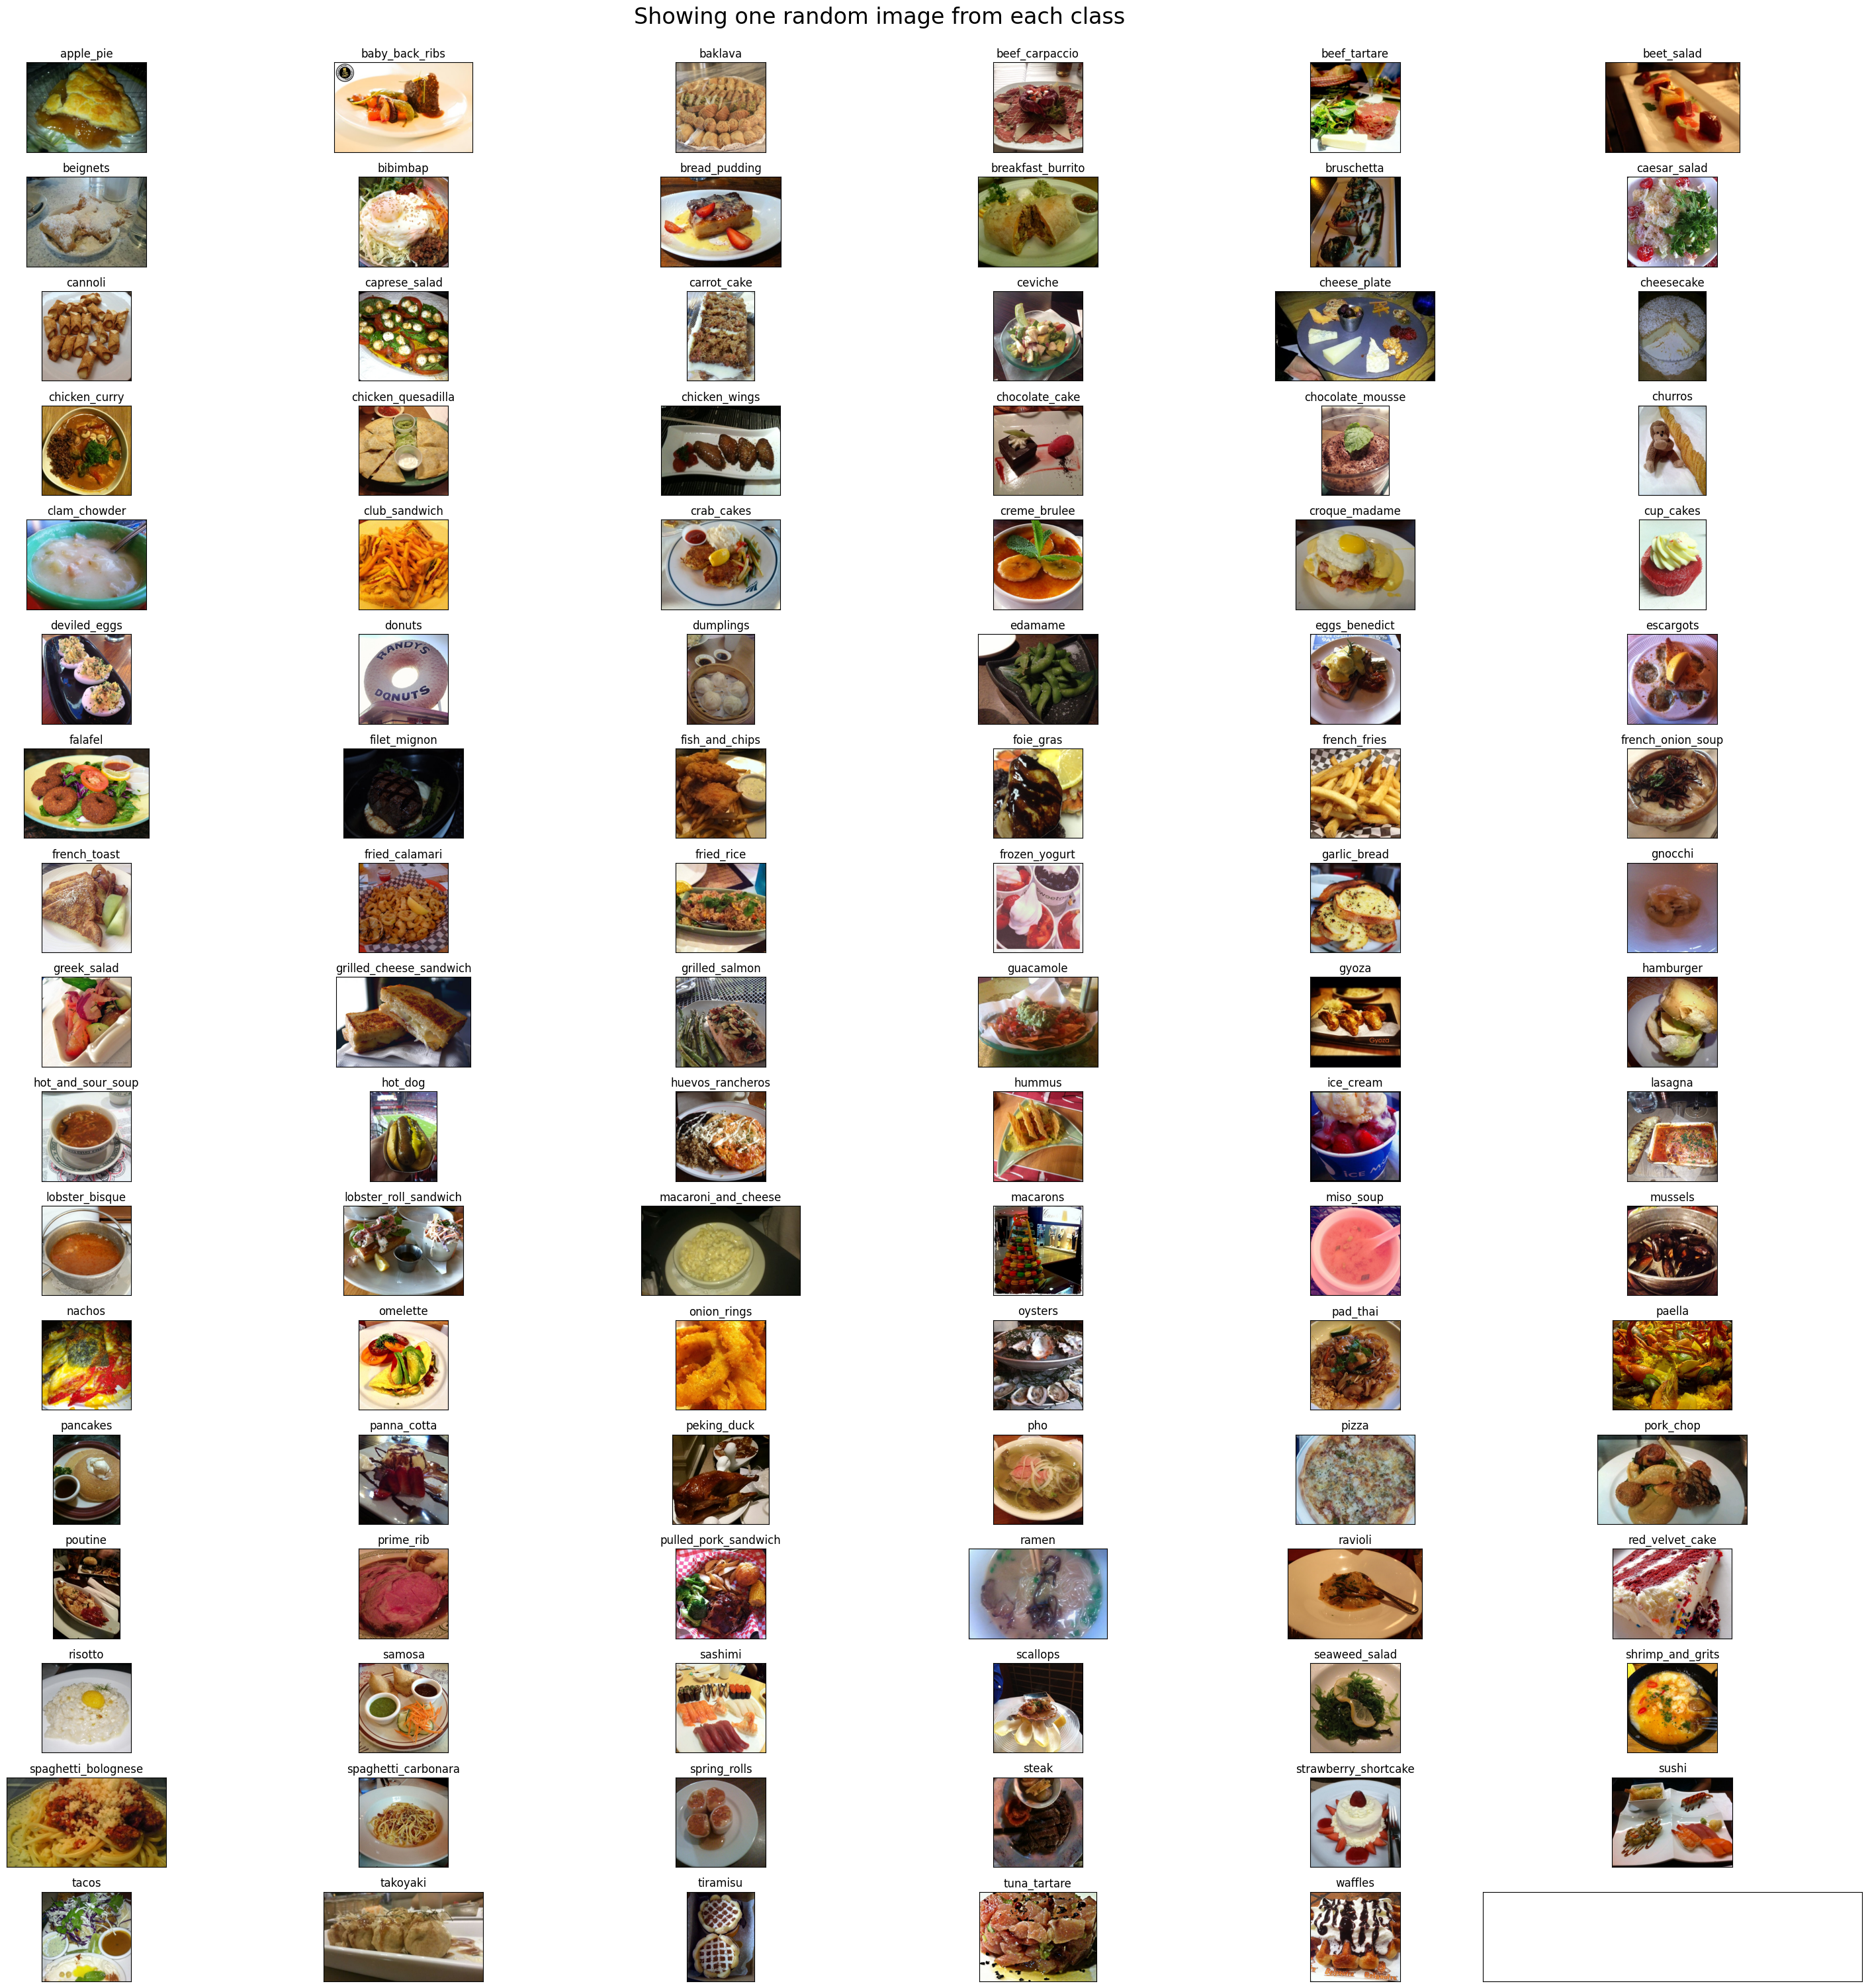

In [5]:
rows = 17
cols = 6
fig, ax = plt.subplots(rows, cols, figsize=(30,30))
fig.suptitle("Showing one random image from each class", y=1, fontsize=24) # y=1 to avoid the title of the figure to overlap with the images
data_dir = "../food-101/images/"
foods_sorted = sorted(os.listdir(data_dir))
food_index = 0
rng = np.random.default_rng(seed=42)  # Create a random number generator with a seed for reproducibility
for i in range(rows):
  for j in range(cols):
    try:
      food_selected = foods_sorted[food_index] 
      food_index += 1
    except:
      break
    if food_selected == '.DS_Store':
        continue
    food_selected_images = os.listdir(os.path.join(data_dir,food_selected)) # list all images in the current food category
    food_selected_random = rng.choice(food_selected_images) # select randomly one image from the list
    img = plt.imread(os.path.join(data_dir,food_selected, food_selected_random))
    ax[i][j].imshow(img)
    ax[i][j].set_title(food_selected)
    
plt.setp(ax, xticks=[],yticks=[])# remove x and y ticks for a cleaner look
plt.tight_layout()

# Split the image data into train and test using train.txt and test.txt

In [6]:
import json

def prepare_data(filepath, src, dest):
    with open(filepath, 'r') as json_file:
        classes_images = json.load(json_file)
        print(classes_images)

    for food in classes_images.keys():
        print("\nCopying images into ", food)
        if not os.path.exists(os.path.join(dest, food)):
            os.makedirs(os.path.join(dest, food))
        for i in classes_images[food]:
            copy(os.path.join(src, i + '.jpg'), os.path.join(dest, i + '.jpg'))
    print("Copying Done!")

Prepare training data

In [7]:
# prepare_data('../food-101/meta/train.json', '../food-101/images', 'food-101/train')

Prepare test data

In [8]:
# prepare_data('../food-101/meta/test.json', '../food-101/images', 'food-101/test')

Base nutritional value (in order: Calories, Protein, Carbs, Fat)

In [4]:
nutrition_info = {
    "apple_pie": [296, 2, 42, 14],
    "baby_back_ribs": [320, 20, 5, 26],
    "baklava": [334, 5, 38, 20],
    "beef_carpaccio": [120, 17, 1, 6],
    "beef_tartare": [164, 19, 2, 9],
    "beet_salad": [110, 2, 10, 7],
    "bibimbap": [490, 15, 74, 12],
    "bread_pudding": [290, 6, 44, 10],
    "breakfast_burrito": [305, 14, 28, 16],
    "bruschetta": [175, 4, 24, 7],
    "caesar_salad": [190, 7, 10, 15],
    "cannoli": [216, 5, 28, 10],
    "caprese_salad": [240, 12, 5, 18],
    "carrot_cake": [326, 3, 45, 16],
    "ceviche": [150, 18, 8, 3],
    "cheesecake": [321, 6, 25, 23],
    "chicken_curry": [290, 20, 8, 20],
    "chicken_quesadilla": [400, 25, 30, 20],
    "chocolate_cake": [352, 5, 50, 16],
    "chocolate_mousse": [310, 6, 32, 19],
    "clam_chowder": [200, 8, 16, 12],
    "club_sandwich": [320, 25, 25, 12],
    "crab_cakes": [190, 15, 10, 10],
    "creme_brulee": [246, 4, 23, 16],
    "croque_madame": [430, 24, 30, 25],
    "deviled_eggs": [62, 3, 1, 5],
    "donuts": [280, 4, 32, 15],
    "dumplings": [250, 8, 30, 10],
    "edamame": [120, 10, 10, 5],
    "eggs_benedict": [390, 15, 22, 27],
    "escargot": [140, 12, 5, 8],
    "falafel": [330, 12, 32, 18],
    "french_fries": [365, 4, 48, 18],
    "french_onion_soup": [200, 7, 25, 8],
    "fried_calamari": [150, 10, 10, 8],
    "fried_rice": [250, 7, 40, 8],
    "guacamole": [230, 3, 12, 20],
    "gyoza": [180, 6, 20, 8],
    "hamburger": [354, 16, 30, 20],
    "hot_dog": [290, 10, 23, 19],
    "lasagna": [375, 20, 35, 20],
    "lobster_bisque": [230, 10, 15, 15],
    "mac_and_cheese": [310, 10, 35, 15],
    "miso_soup": [50, 3, 5, 2],
    "nachos": [430, 10, 40, 28],
    "omelette": [240, 14, 2, 20],
    "onion_rings": [400, 5, 40, 22],
    "oysters": [110, 10, 5, 5],
    "pad_thai": [400, 14, 50, 14],
    "pancakes": [350, 8, 60, 10],
    "peking_duck": [340, 20, 10, 25],
    "pho": [350, 20, 40, 10],
    "pizza": [285, 12, 36, 10],
    "pork_chop": [290, 25, 0, 20],
    "poutine": [740, 19, 82, 40],
    "prime_rib": [400, 25, 0, 35],
    "pulled_pork_sandwich": [350, 20, 30, 15],
    "ramen": [450, 15, 60, 15],
    "ravioli": [300, 12, 40, 10],
    "red_velvet_cake": [430, 6, 55, 20],
    "risotto": [300, 8, 40, 10],
    "samosa": [260, 5, 30, 15],
    "sashimi": [140, 20, 0, 6],
    "scallops": [140, 20, 5, 5],
    "shrimp_and_grits": [400, 20, 35, 20],
    "spaghetti_bolognese": [420, 20, 50, 15],
    "spaghetti_carbonara": [370, 15, 45, 12],
    "spring_rolls": [200, 5, 30, 6],
    "steak": [271, 25, 0, 18],
    "strawberry_shortcake": [350, 5, 50, 15],
    "sushi": [200, 8, 28, 5],
    "tacos": [220, 12, 20, 10],
    "takoyaki": [320, 10, 30, 15],
    "tiramisu": [340, 6, 40, 18],
    "tuna_tartare": [150, 20, 5, 5],
    "waffles": [310, 8, 45, 12]
}


Randomizing nutritional value to each images

In [5]:
from IPython.display import Image
import pandas as pd

variability = {
    "calories": 0.1,  # ±10%
    "protein": 0.15,  # ±15%
    "carbs": 0.2,     # ±20%
    "fat": 0.15       # ±15%
}

def apply_variability(base_value, percentage):
    delta = base_value * percentage
    return round(random.uniform(base_value - delta, base_value + delta), 2)

train_dataset_path='../food-101/train'
test_dataset_path = '../food-101/test'

# Initialize a list to store image paths and synthetic values
augmented_train_data = []
augmented_test_data=[]

for category in os.listdir(train_dataset_path):
    category_path = os.path.join(train_dataset_path, category)

    if os.path.isdir(category_path) and category in nutrition_info:
        base_values = nutrition_info[category]
        
        for image in os.listdir(category_path):
            image_path = os.path.join(category_path, image)
            synthetic_values = [
                apply_variability(base_values[0], variability["calories"]),  # Calories
                apply_variability(base_values[1], variability["protein"]),   # Protein
                apply_variability(base_values[2], variability["carbs"]),     # Carbs
                apply_variability(base_values[3], variability["fat"])        # Fat
            ]
            augmented_train_data.append([image_path] + synthetic_values)

for category in os.listdir(test_dataset_path):
    category_path = os.path.join(test_dataset_path, category)

    if os.path.isdir(category_path) and category in nutrition_info:
        base_values = nutrition_info[category]
        
        for image in os.listdir(category_path):
            image_path = os.path.join(category_path, image)
            synthetic_values = [
                apply_variability(base_values[0], variability["calories"]),  # Calories
                apply_variability(base_values[1], variability["protein"]),   # Protein
                apply_variability(base_values[2], variability["carbs"]),     # Carbs
                apply_variability(base_values[3], variability["fat"])        # Fat
            ]
            augmented_test_data.append([image_path] + synthetic_values)

display(augmented_train_data[0])
Image(filename=augmented_train_data[100][0])

columns = ["image_path", "calories", "protein", "carbs", "fat"]
df_train_augmented = pd.DataFrame(augmented_train_data, columns=columns)
df_test_augmented = pd.DataFrame(augmented_test_data, columns=columns)

display(df_train_augmented.head())

# Save the augmented dataset to a CSV
df_train_augmented.to_csv("augmented_training_dataset.csv", index=False)
df_test_augmented.to_csv("augmented_test_dataset.csv", index=False)

print("Synthetic variability applied and dataset saved!")

['../food-101/train\\apple_pie\\1005649.jpg', 312.78, 1.72, 43.6, 11.95]

,image_path,calories,protein,carbs,fat
0,../food-101/train\apple_pie\1005649.jpg,312.78,1.72,43.60,11.95
1,../food-101/train\apple_pie\1014775.jpg,287.68,1.98,36.69,15.01
2,../food-101/train\apple_pie\1026328.jpg,299.37,1.99,46.45,13.38
3,../food-101/train\apple_pie\1028787.jpg,284.33,1.92,43.45,13.06
4,../food-101/train\apple_pie\1043283.jpg,318.64,1.73,40.58,13.55


Synthetic variability applied and dataset saved!


Split into train and validation sets

In [6]:
from sklearn.model_selection import train_test_split

augmented_training_dataset = pd.read_csv("augmented_training_dataset.csv")
test_df = pd.read_csv("augmented_test_dataset.csv")

train_df, val_df = train_test_split(augmented_training_dataset, test_size=0.1, random_state=42)

In [12]:
val_df

,image_path,calories,protein,carbs,fat
31641,../food-101/train\nachos\1716412.jpg,447.75,8.76,42.83,29.30
9246,../food-101/train\caprese_salad\2289067.jpg,258.84,11.65,5.91,18.62
1583,../food-101/train\baklava\1391969.jpg,360.37,5.56,42.80,19.36
36506,../food-101/train\peking_duck\3369310.jpg,306.84,19.52,10.31,23.06
11259,../food-101/train\cheesecake\1055684.jpg,352.54,6.18,21.98,20.08
...,...,...,...,...,...
30799,../food-101/train\miso_soup\120774.jpg,47.87,3.08,5.45,1.82
36334,../food-101/train\peking_duck\2561375.jpg,335.63,22.96,9.16,25.45
43559,../food-101/train\risotto\1302909.jpg,275.94,8.72,45.58,11.04
31579,../food-101/train\nachos\1414031.jpg,394.71,10.94,45.15,30.34


In [13]:
train_images = train_df["image_path"].tolist()
train_values = train_df[["calories", "protein", "carbs", "fat"]].values
val_images = val_df["image_path"].tolist()
val_values = val_df[["calories", "protein", "carbs", "fat"]].values
test_images = test_df["image_path"].tolist()
test_values = test_df[["calories", "protein", "carbs", "fat"]].values

In [14]:
test_values

array([[318.44,   2.29,  37.91,  12.11],
       [318.73,   2.  ,  40.03,  15.24],
       [285.59,   2.07,  43.41,  14.04],
       ...,
       [311.12,   8.77,  39.56,  10.91],
       [323.26,   8.13,  36.27,  12.77],
       [299.15,   8.47,  53.99,  11.62]])

In [15]:
# Preprocessing function for MobileNet
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)  # Decode the image
    image = tf.image.resize(image, [224, 224])      # Resize to MobileNet input size
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)  # Normalize
    return image, label

# Create a dataset
def create_dataset(image_paths, labels, batch_size=32, augment=False):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        dataset = dataset.map(lambda x, y: (tf.image.random_flip_left_right(x), y))

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Create train, validation, and test datasets
train_dataset = create_dataset(train_images, train_values, augment=True)
val_dataset = create_dataset(val_images, val_values)
test_dataset = create_dataset(test_images, test_values)

In [16]:
from tensorflow.keras import layers, models

# Load MobileNetV2 without the top layer
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # Freeze the base model

# Add a regression head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(4)  # 4 outputs: calories, protein, carbs, fat
])

# Compile the model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [17]:
# Train the model
# history = model.fit(
#     train_dataset,
#     validation_data=val_dataset,
#     epochs=10,  # Start with 10 epochs; increase if necessary
#     batch_size=32
# )

Epoch 1/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 169s 107ms/step - loss: 4811.5234 - mae: 32.6504 - val_loss: 2528.0957 - val_mae: 24.3879
Epoch 2/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 177s 113ms/step - loss: 2392.2295 - mae: 23.8350 - val_loss: 2310.3787 - val_mae: 23.3656
Epoch 3/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 178s 114ms/step - loss: 2215.6025 - mae: 22.9713 - val_loss: 2207.9241 - val_mae: 22.8560
Epoch 4/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 182s 116ms/step - loss: 2114.0664 - mae: 22.4275 - val_loss: 2144.9675 - val_mae: 22.5656
Epoch 5/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 181s 116ms/step - loss: 2045.2939 - mae: 22.0815 - val_loss: 2090.4431 - val_mae: 22.3123
Epoch 6/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 182s 116ms/step - loss: 1981.3469 - mae: 21.7243 - val_loss: 2040.6608 - val_mae: 22.0720
Epoch 7/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 173s 111ms/step - loss: 1923.5121 - mae: 21.4257 - val_loss: 2008.4126 - val_mae: 21.9061
Epoch 8/10
1561/1561 ━━━━━━━━━━━━━━━━━━━━ 183s 117ms/step - loss: 1880.3947 

In [18]:

# Save the model
model.save("../food-101/food_nutrition_model.keras")

In [19]:
test_loss, test_mae = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

579/579 ━━━━━━━━━━━━━━━━━━━━ 69s 118ms/step - loss: 1649.9465 - mae: 20.3077
Test Loss: 1797.7572021484375, Test MAE: 20.667083740234375


In [20]:
def predict(image_path):
    # Preprocess the input image
    image = preprocess_image(image_path, None)[0]
    image = tf.expand_dims(image, axis=0)  # Add batch dimension

    # Predict using the model
    prediction = model.predict(image)
    return prediction

# Test with a new image
image_path = "phobohanoi.jpg"
predicted_values = predict(image_path)
print("Predicted Nutrition (calories, protein, carbs, fat):", predicted_values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
Predicted Nutrition (calories, protein, carbs, fat): [[383.56003   15.814964  47.529465  11.585894]]
